# Day 12 — Visualization & Exploratory Data Analysis
Communicate data with charts and run a proper EDA.
Dataset: Titanic passenger data

## 1. Setup & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Distributions — Histograms

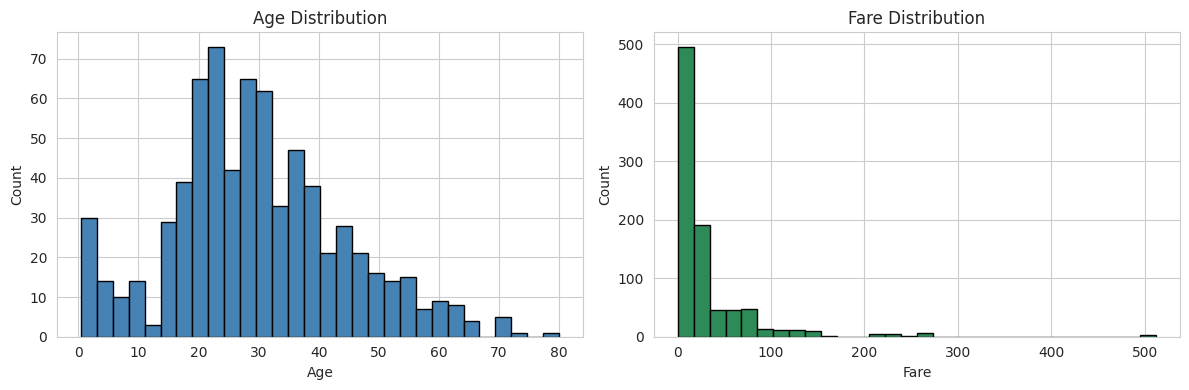

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Age"].dropna(), bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].hist(df["Fare"], bins=30, color="seagreen", edgecolor="black")
axes[1].set_title("Fare Distribution")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3. Outliers — Box Plots

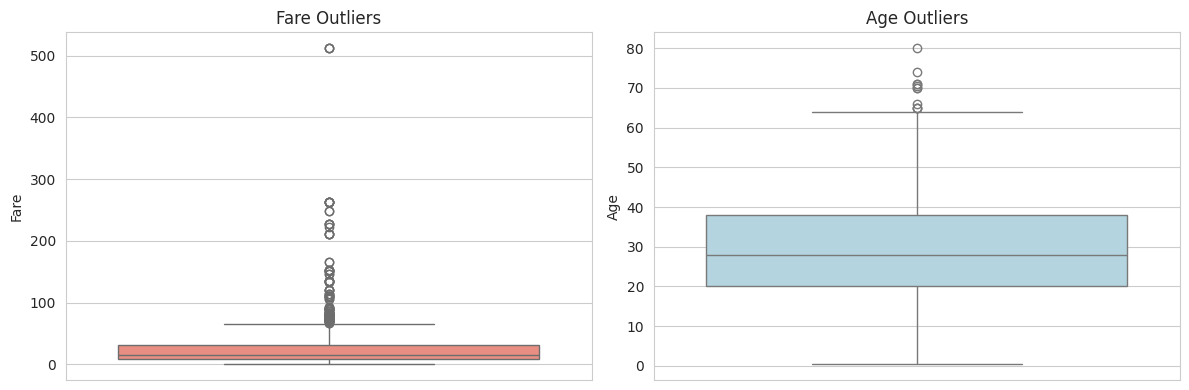

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["Fare"], ax=axes[0], color="salmon")
axes[0].set_title("Fare Outliers")

sns.boxplot(y=df["Age"], ax=axes[1], color="lightblue")
axes[1].set_title("Age Outliers")

plt.tight_layout()
plt.show()

## 4. Relationships — Scatter Plot

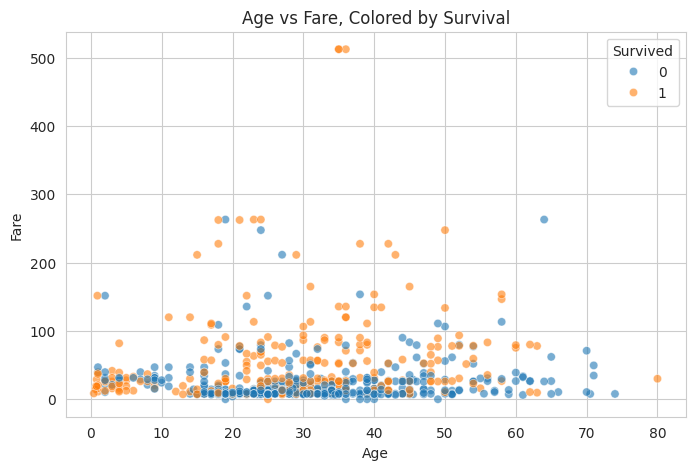

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", alpha=0.6)
plt.title("Age vs Fare, Colored by Survival")
plt.show()

## 5. Categorical Relationships

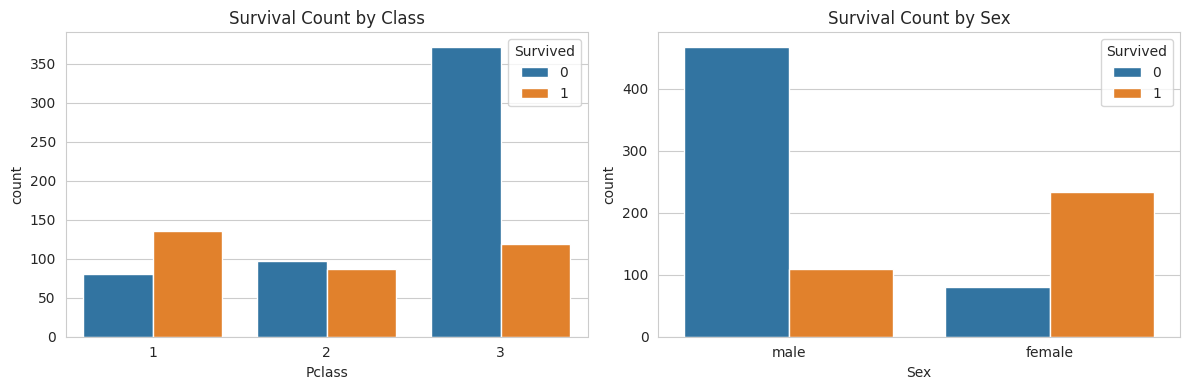

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[0])
axes[0].set_title("Survival Count by Class")

sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[1])
axes[1].set_title("Survival Count by Sex")

plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

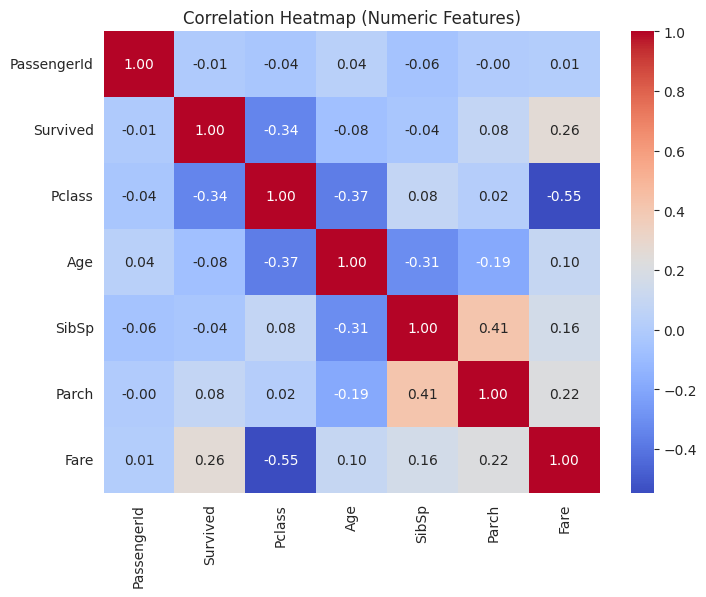

In [6]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

7. Written Findings

Distributions: Age is roughly bell-shaped around 20–40, while Fare is strongly right-skewed, with most tickets being cheap and a few very expensive fares.

Outliers: Fare has clear high-value outliers, mainly from premium first-class tickets. Age has a few older passengers but no unrealistic extreme values.

Relationships: Age and Fare show no strong linear relationship, but higher fares are associated with more survivors. First-class passengers and women also had noticeably higher survival rates than third-class passengers and men.

Correlation: Fare has a positive correlation with Survived, while Pclass has a negative correlation because lower Pclass values represent higher social class. Both indicate that higher socioeconomic status was associated with better survival chances.

Conclusion: Class and gender were the strongest visible factors linked to survival, with Fare acting as a proxy for class.